# Build Logit Masking from Scratch

### From "why does AI give different answers?" to "how do I make it NEVER say that?"

**Picture this:** You're using AI to write product descriptions for your luxury brand. It writes: *"This exquisite timepiece embodies Swiss precision."* Beautiful. You run it again with the same input. It writes: *"This affordable watch offers great value."*

Wait. Same prompt, different output. And "affordable"? For a luxury brand? That word should *never* appear.

**How do you guarantee it never does?**

By the end of this notebook, you'll understand exactly what's happening inside the model, why traditional controls can't solve this, and how logit masking gives you **absolute guarantees**.

---
*Let's start by looking inside the machine.*

## 1. Setup

We'll use GPT-2 — small enough to run on any machine, but real enough to show every concept. Everything we build here works identically with Llama, Mistral, GPT-4, or any transformer.

> **Note:** Logit masking requires access to the model's raw logits. This works with open-source models and APIs that expose logprobs (OpenAI, Anthropic, etc.).
> 
> **Why GPT-2?** It's completely open, runs on CPU, and gives us full access to the raw logit tensor — the 50,257-dimensional vector of scores that we'll learn to manipulate.

In [1]:
import torch
import torch.nn.functional as F
from transformers import GPT2LMHeadModel, GPT2Tokenizer
import math
import copy
import warnings
warnings.filterwarnings("ignore", message=".*IProgress not found.*")
warnings.filterwarnings("ignore", message=".*attention mask.*")

# Load a real language model
print("Loading GPT-2...")
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token  # Suppress attention mask warnings
model = GPT2LMHeadModel.from_pretrained("gpt2")
model.eval()

print(f"Model loaded!")
print(f"Vocabulary size: {tokenizer.vocab_size:,} tokens")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

Loading GPT-2...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Model loaded!
Vocabulary size: 50,257 tokens
Parameters: 124,439,808


## 2. The Obvious Approach: "Just Use a Better Prompt"

Before we go deep, let's try what most people try first. You're building a product description generator for a luxury watch brand. The words **"cheap", "affordable", "budget", "bargain", "basic"** must NEVER appear.

The intuitive fix? **Tell the model not to use them.**

In [3]:
# =============================================================
# ATTEMPT 1: Can prompt engineering control the output?
# =============================================================
# The idea: Tell the model "NEVER use these words" in the prompt.
# The hope: The model will obey.
# The reality: Let's find out.
# =============================================================

import re
import textwrap

prompt_engineered = (
    "You are a luxury brand copywriter. Write a one-sentence product description "
    "for a premium Swiss watch. IMPORTANT: Never use the words cheap, affordable, "
    "budget, bargain, basic, inexpensive, or low-cost. Use only premium, elegant, "
    "luxury language. Description: This"
)

# Words that should NEVER appear in luxury brand copy
banned_words = ["cheap", "affordable", "budget", "bargain", "basic",
                "inexpensive", "low-cost", "discount", "economical"]


def find_banned_words(text, banned_list):
    """
    Check if any banned words appear in the generated text.

    Uses regex word boundaries (\\b) so we only catch exact matches:
      - "cheap" matches, but "cheaply" does NOT
      - "basic" matches, but "basically" does NOT

    Returns: list of banned words found (empty = clean output)
    """
    found = []
    text_lower = text.lower()
    for word in banned_list:
        if re.search(r'\b' + re.escape(word) + r'\b', text_lower):
            found.append(word)
    return found


# --- Run the experiment ---
print("ATTEMPT 1: Control output with prompt engineering")
print("=" * 60)
print()
print("Strategy: Tell GPT-2 'NEVER use these words' in the prompt")
print(f"Banned words: {banned_words}")
print(f"Generating 50 product descriptions...\n")

inputs = tokenizer.encode(prompt_engineered, return_tensors='pt')
attention_mask = torch.ones_like(inputs)
violations = []

for i in range(50):
    # Generate one product description
    with torch.no_grad():
        output = model.generate(
            inputs,
            attention_mask=attention_mask,
            max_new_tokens=30,
            do_sample=True,       # Enable sampling (randomness)
            temperature=0.7,      # Moderate creativity
            top_p=0.9,            # Nucleus sampling
            pad_token_id=tokenizer.eos_token_id,
        )

    # Decode only the NEW tokens (skip the prompt)
    text = tokenizer.decode(output[0][len(inputs[0]):], skip_special_tokens=True)

    # Scan for banned words
    found = find_banned_words(text, banned_words)
    if found:
        violations.append((i + 1, text.strip(), found))

# --- Display results ---
print(f"  Results: {len(violations)} violations in 50 generations")
print(f"  Violation rate: {len(violations)/50*100:.0f}%")
print()

if violations:
    print("  Examples of prompt engineering FAILING:")
    print("  " + "-" * 56)
    for run_num, text, words in violations[:4]:
        # Wrap long text so nothing gets cut off
        wrapped = textwrap.fill(text[:1000], width=52, initial_indent="    ",
                                subsequent_indent="    ")
        print(f"  Run {run_num:2d}: {wrapped}")
        print(f"         Banned: {words}")
        print()

print("  " + "=" * 56)
print("  VERDICT: We TOLD the model 'never use these words'")
print("           — it did anyway. Prompt engineering is a")
print("           SUGGESTION, not a GUARANTEE.")

ATTEMPT 1: Control output with prompt engineering

Strategy: Tell GPT-2 'NEVER use these words' in the prompt
Banned words: ['cheap', 'affordable', 'budget', 'bargain', 'basic', 'inexpensive', 'low-cost', 'discount', 'economical']
Generating 50 product descriptions...

  Results: 10 violations in 50 generations
  Violation rate: 20%

  Examples of prompt engineering FAILING:
  --------------------------------------------------------
  Run  2:     watch is not a cheap luxury watch. It is a
    luxury brand copywriter's watch. IMPORTANT:
    Never use the words cheap, affordable,
         Banned: ['cheap', 'affordable']

  Run  3:     is a luxury brand watch. IMPORTANT: Never use
    the words cheap, affordable, budget, bargain,
    basic, inexpensive, or low-cost
         Banned: ['cheap', 'affordable', 'budget', 'bargain', 'basic', 'inexpensive', 'low-cost']

  Run  4:     watch is one of those watches that has been
    designed with high quality in mind. It is also
    very elegant. I

### Prompt engineering is a suggestion, not a guarantee.

You can add "NEVER use these words" in all caps, bold, repeated 10 times — and the model will **still** occasionally produce them. Why? Because:

1. The model doesn't have a "banned words list" — it computes probabilities over its **entire vocabulary** every time
2. Your instruction influences the distribution but can't make any probability **exactly zero**
3. At scale (thousands of API calls), even a 1% failure rate means **dozens of brand violations**

> **This is like telling a chef "never use salt" — they'll try their best, but muscle memory kicks in. You need to remove the salt from the kitchen entirely.**

OK so prompt engineering won't cut it. Let's understand WHY by going deeper — what's actually happening inside the model?

## 3. The Deterministic Core of an LLM

Here's the first mind-bending fact: **language models are deterministic.**

Same input → same logits → same probabilities. Every single time.

Most people think LLMs are "random" or "creative." They're not. The math is a pure function. Let's prove it.

In [4]:
def peek_inside_the_brain(prompt):
    """
    Look at what the model is "thinking" for the next word.

    How it works, step by step:
    1. Encode the prompt into token IDs (numbers the model understands)
    2. Run the forward pass — the model scores ALL 50,257 tokens
    3. Convert those scores (logits) into probabilities via softmax
    4. Show the top 10 most likely next tokens

    This is like reading the model's mind — seeing which words
    it considers most likely BEFORE it randomly picks one.
    """
    # Step 1: Convert text to token IDs
    inputs = tokenizer.encode(prompt, return_tensors='pt')

    # Step 2: Run the model (forward pass)
    # torch.no_grad() = we're just looking, not training
    with torch.no_grad():
        outputs = model(inputs)
        # outputs.logits shape: [1, seq_len, 50257]
        # We want the LAST position (prediction for next token)
        logits = outputs.logits[0, -1]  # shape: [50257]

    # Step 3: Logits → Probabilities
    probabilities = torch.softmax(logits, dim=-1)

    # Step 4: Show top 10
    top_probs, top_indices = torch.topk(probabilities, 10)

    print(f"  Prompt: '{prompt}'")
    print(f"  Model scores all {len(logits):,} tokens, top 10:")
    print("  " + "-" * 46)
    for i, (prob, token_id) in enumerate(zip(top_probs, top_indices)):
        token = tokenizer.decode([token_id])
        bar = "█" * max(1, int(prob.item() * 100 / 3))
        print(f"    {i+1:2d}. '{token:12s}' {prob.item()*100:5.1f}%  {bar}")

    return probabilities


def test_determinism(prompt="This luxury watch is"):
    """
    PROVE that the model's forward pass is deterministic.

    We run the EXACT same input through the model TWICE
    and compare all 50,257 probability values.
    If they're identical → the model is a pure function.
    """
    print("  TESTING: Is the forward pass deterministic?")
    print("  " + "=" * 46)

    inputs = tokenizer.encode(prompt, return_tensors='pt')

    # Run 1
    with torch.no_grad():
        probs1 = torch.softmax(model(inputs).logits[0, -1], dim=-1)

    # Run 2 — SAME input
    with torch.no_grad():
        probs2 = torch.softmax(model(inputs).logits[0, -1], dim=-1)

    # Compare all 50,257 values
    identical = torch.allclose(probs1, probs2, atol=1e-6)

    print(f"  Prompt: '{prompt}'")
    print(f"  Run 1: computed {len(probs1):,} probabilities")
    print(f"  Run 2: computed {len(probs2):,} probabilities")
    print(f"  Identical? {identical}")
    print()

    if identical:
        print("  ✓ PROVEN: The forward pass is 100% deterministic!")
        print("    Same input → same logits → same probabilities.")
        print("    Randomness must come from somewhere ELSE...")
    return identical


# --- Run both demos ---
print("INSIDE THE MODEL'S BRAIN")
print("=" * 52)
print()
probs = peek_inside_the_brain("This luxury watch is")
print()
test_determinism()

INSIDE THE MODEL'S BRAIN

  Prompt: 'This luxury watch is'
  Model scores all 50,257 tokens, top 10:
  ----------------------------------------------
     1. ' a          '   8.4%  ██
     2. ' made       '   5.7%  █
     3. ' the        '   4.2%  █
     4. ' available  '   4.1%  █
     5. ' designed   '   3.9%  █
     6. ' also       '   3.6%  █
     7. ' not        '   2.2%  █
     8. ' an         '   2.2%  █
     9. ' one        '   2.0%  █
    10. ' built      '   1.4%  █

  TESTING: Is the forward pass deterministic?
  Prompt: 'This luxury watch is'
  Run 1: computed 50,257 probabilities
  Run 2: computed 50,257 probabilities
  Identical? True

  ✓ PROVEN: The forward pass is 100% deterministic!
    Same input → same logits → same probabilities.
    Randomness must come from somewhere ELSE...


True

### Let that sink in.

The model isn't "deciding" anything. It's computing a probability distribution, and that computation is a **pure function**. Same input, same output, every time.

**This is crucial:** if the model is deterministic, where does the variety come from?

## 4. The Randomness Reveal

The randomness is in the **sampling**. After the model computes probabilities, we roll dice.

**The analogy:** Imagine a weighted die. The weights are fixed (deterministic), but each roll gives a different result (random). The model is the weights. Sampling is the roll.

In [5]:
def demonstrate_sampling_randomness(prompt="This luxury watch is",
                                    num_samples=5):
    """
    Show that SAME probabilities → DIFFERENT outputs.

    The model computes identical probabilities every time (proven above).
    But sampling = rolling weighted dice. Each roll gives a different result.

    Think of a roulette wheel:
      - The wheel (probabilities) never changes
      - But each spin lands on a different slot
    """
    print("SAMPLING RANDOMNESS")
    print("=" * 55)
    print(f"  Prompt: '{prompt}'")
    print(f"  Same prompt → same probabilities → different samples:")
    print("  " + "-" * 51)

    inputs = tokenizer.encode(prompt, return_tensors='pt')
    attention_mask = torch.ones_like(inputs)

    for i in range(num_samples):
        with torch.no_grad():
            output = model.generate(
                inputs,
                attention_mask=attention_mask,
                max_new_tokens=8,
                do_sample=True,     # THIS is where randomness enters
                temperature=1.0,
                pad_token_id=tokenizer.eos_token_id,
            )
        # Decode only the newly generated tokens
        new_tokens = output[0][len(inputs[0]):]
        generated = tokenizer.decode(new_tokens, skip_special_tokens=True)
        print(f"    Sample {i+1}: '{prompt} {generated.strip()}'")

    print()
    print("  Key Insight:")
    print("    Same input → same probabilities  (deterministic)")
    print("    Same probs → different samples   (random)")
    print("    Randomness lives ONLY in sampling!")

demonstrate_sampling_randomness()

SAMPLING RANDOMNESS
  Prompt: 'This luxury watch is'
  Same prompt → same probabilities → different samples:
  ---------------------------------------------------
    Sample 1: 'This luxury watch is a work in progress. It's something'
    Sample 2: 'This luxury watch is the culmination of two year research, as'
    Sample 3: 'This luxury watch is the third in the series.'
    Sample 4: 'This luxury watch is now on sale. The smartwatch can'
    Sample 5: 'This luxury watch is the first to be produced in Switzerland,'

  Key Insight:
    Same input → same probabilities  (deterministic)
    Same probs → different samples   (random)
    Randomness lives ONLY in sampling!


In [6]:
# =============================================================
# UNDER THE HOOD: Where does the randomness actually live?
# =============================================================
# model.generate() hides the random step inside.
# Let's pull it apart and SEE the exact function call
# that introduces randomness: torch.multinomial()
#
# torch.multinomial(probs, num_samples=1)
#   → Rolls a weighted dice using the probability distribution
#   → Different result each time, even with IDENTICAL probs
# =============================================================

prompt = "This luxury watch is"
inputs = tokenizer.encode(prompt, return_tensors='pt')

# Step 1: Forward pass — get the raw logits (DETERMINISTIC)
with torch.no_grad():
    outputs = model(inputs)
    logits = outputs.logits[0, -1, :]  # last token's logits

# Step 2: Softmax — convert to probabilities (DETERMINISTIC)
probs = torch.softmax(logits, dim=-1)

# Show top 5 probabilities (these NEVER change)
top5 = torch.topk(probs, 5)
print("THE PROBABILITY DISTRIBUTION (never changes)")
print("=" * 55)
for i in range(5):
    token = tokenizer.decode(top5.indices[i])
    prob = top5.values[i].item()
    bar = "█" * int(prob * 200)
    print(f"  '{token:>12s}'  →  {prob:.4f}  {bar}")

print()
print("NOW ROLL THE DICE 5 TIMES (torch.multinomial)")
print("=" * 55)

# Step 3: Sample — THIS is the only random step
for roll in range(1, 6):
    # This single line is where ALL randomness lives
    sampled_id = torch.multinomial(probs, num_samples=1)
    token = tokenizer.decode(sampled_id)
    prob = probs[sampled_id].item()
    print(f"  Roll {roll}: picked '{token}' (prob = {prob:.4f})")

print()
print("  Same probabilities. Same dice.")
print("  Different roll each time.")
print()
print("  torch.multinomial() = the ONLY random function")
print("  in the entire generation pipeline.")

THE PROBABILITY DISTRIBUTION (never changes)
  '           a'  →  0.0844  ████████████████
  '        made'  →  0.0566  ███████████
  '         the'  →  0.0424  ████████
  '   available'  →  0.0408  ████████
  '    designed'  →  0.0391  ███████

NOW ROLL THE DICE 5 TIMES (torch.multinomial)
  Roll 1: picked ' available' (prob = 0.0408)
  Roll 2: picked ' been' (prob = 0.0003)
  Roll 3: picked ' paid' (prob = 0.0001)
  Roll 4: picked ' priced' (prob = 0.0060)
  Roll 5: picked ' a' (prob = 0.0844)

  Same probabilities. Same dice.
  Different roll each time.

  torch.multinomial() = the ONLY random function
  in the entire generation pipeline.


### The boundary is now clear

```
prompt --> [MODEL: deterministic] --> logits --> probabilities --> [SAMPLING: random] --> output
                                                                        ^
                                                              This is the ONLY random part
```

Now that we see the boundary, let's ask: **how do we control what gets sampled?**

## 5. The Traditional Controls (and Why They're Not Enough)

People usually reach for three knobs: **temperature**, **top-k**, and **top-p**. Let's understand each one — and then see where they all fail.

### 5.1 Temperature — Reshaping the Curve

Temperature divides logits before softmax. It's like adjusting the "confidence" of the distribution.

In [7]:
def demonstrate_temperature(prompt="This luxury watch is",
                            temperatures=[0.1, 1.0, 2.0]):
    """
    Show how temperature reshapes the probability distribution.

    Temperature DIVIDES the logits before softmax:
      scaled_logits = logits / temperature

    Low temp (0.1) → divides by 0.1 = MULTIPLIES by 10
                     → differences become HUGE → sharp peaks
    High temp (2.0) → divides by 2 = halves the differences
                     → differences shrink → flat distribution

    Analogy: Temperature is like a "confidence dial"
      - Low = "I'm very sure, pick the top word"
      - High = "I'm open to anything, surprise me"
    """
    print("TEMPERATURE EFFECTS")
    print("=" * 55)
    print(f"  Prompt: '{prompt}'")

    inputs = tokenizer.encode(prompt, return_tensors='pt')

    with torch.no_grad():
        base_logits = model(inputs).logits[0, -1]

    for temp in temperatures:
        # THE KEY OPERATION: divide logits by temperature
        scaled_logits = base_logits / temp
        probs = torch.softmax(scaled_logits, dim=-1)
        top_probs, top_indices = torch.topk(probs, 5)

        label = {0.1: "SHARP (confident)", 1.0: "NORMAL",
                 2.0: "FLAT (creative)"}.get(temp, "")

        print(f"\n  Temperature = {temp}  [{label}]")
        print("  " + "-" * 42)
        for prob, idx in zip(top_probs, top_indices):
            token = tokenizer.decode([idx])
            bar = "█" * max(1, int(prob.item() * 100 / 3))
            print(f"    '{token:12s}' {prob.item()*100:5.1f}%  {bar}")

demonstrate_temperature()

TEMPERATURE EFFECTS
  Prompt: 'This luxury watch is'

  Temperature = 0.1  [SHARP (confident)]
  ------------------------------------------
    ' a          '  98.0%  ████████████████████████████████
    ' made       '   1.8%  █
    ' the        '   0.1%  █
    ' available  '   0.1%  █
    ' designed   '   0.0%  █

  Temperature = 1.0  [NORMAL]
  ------------------------------------------
    ' a          '   8.4%  ██
    ' made       '   5.7%  █
    ' the        '   4.2%  █
    ' available  '   4.1%  █
    ' designed   '   3.9%  █

  Temperature = 2.0  [FLAT (creative)]
  ------------------------------------------
    ' a          '   0.6%  █
    ' made       '   0.5%  █
    ' the        '   0.4%  █
    ' available  '   0.4%  █
    ' designed   '   0.4%  █


**Low temperature (0.1):** Sharp peaks. The model is "very confident" — almost always picks the top token.

**High temperature (2.0):** Flat landscape. Probabilities spread out, more randomness.

Temperature controls **HOW** we pick from the distribution. But notice: it doesn't remove any options from the menu.

### 5.2 Top-K and Top-P

**Top-K:** Keep only the K most probable tokens, zero out everything else.
**Top-P (nucleus):** Keep the smallest set of tokens whose cumulative probability exceeds P.

In [8]:
def demonstrate_top_k_top_p(prompt="This luxury watch is"):
    """
    Show how Top-K and Top-P reduce the candidate pool.

    Top-K = "Keep only the K most probable tokens"
      - K=5  → only 5 tokens to choose from
      - K=100 → 100 tokens (still a tiny fraction of 50,257)

    Top-P = "Keep the smallest set whose probabilities sum to P"
      - P=0.5 → keep tokens until cumulative prob reaches 50%
      - P=0.95 → keep tokens until cumulative prob reaches 95%

    Both SHRINK the pool but neither can TARGET specific words.
    They don't know "cheap" is bad — they only know probability ranks.
    """
    inputs = tokenizer.encode(prompt, return_tensors='pt')

    with torch.no_grad():
        logits = model(inputs).logits[0, -1]
    probs = torch.softmax(logits, dim=-1)

    print("TOP-K: Keep only the K most probable tokens")
    print("=" * 55)
    for k in [5, 20, 100]:
        top_k_probs, _ = torch.topk(probs, k)
        mass = top_k_probs.sum().item()
        pct = k / len(probs) * 100
        print(f"  K = {k:3d} → keeps {k:3d} tokens "
              f"({pct:.2f}% of vocab), "
              f"captures {mass*100:.1f}% of probability")

    print()
    print("TOP-P: Keep smallest set with cumulative prob >= P")
    print("=" * 55)
    sorted_probs, _ = torch.sort(probs, descending=True)
    cumsum = torch.cumsum(sorted_probs, dim=0)

    for p in [0.5, 0.8, 0.95]:
        nucleus_size = (cumsum <= p).sum().item() + 1
        pct = nucleus_size / len(probs) * 100
        print(f"  P = {p:.2f} → keeps {nucleus_size:5d} tokens "
              f"({pct:.2f}% of vocab)")

    print()
    print("  Notice: Both methods filter by PROBABILITY RANK,")
    print("  not by MEANING. They can't tell 'cheap' from 'luxury'.")

demonstrate_top_k_top_p()

TOP-K: Keep only the K most probable tokens
  K =   5 → keeps   5 tokens (0.01% of vocab), captures 26.3% of probability
  K =  20 → keeps  20 tokens (0.04% of vocab), captures 46.5% of probability
  K = 100 → keeps 100 tokens (0.20% of vocab), captures 68.4% of probability

TOP-P: Keep smallest set with cumulative prob >= P
  P = 0.50 → keeps    27 tokens (0.05% of vocab)
  P = 0.80 → keeps   252 tokens (0.50% of vocab)
  P = 0.95 → keeps  1571 tokens (3.13% of vocab)

  Notice: Both methods filter by PROBABILITY RANK,
  not by MEANING. They can't tell 'cheap' from 'luxury'.


These look useful, right? They reduce the pool of candidates. But here's the thing...

### 5.3 The Stress Test — Let's Run It 200 Times

Theory is one thing. Let's actually **prove** that temperature, top-k, and top-p can't protect us. We'll generate product descriptions with the tightest settings and scan every single one for banned words.

In [ ]:
def stress_test_traditional_controls(prompt="This luxury watch is",
                                     num_runs=500):
    """
    The definitive test: run each control strategy 500 times
    and count how many times banned words slip through.

    We test 4 configurations, from loose to strictest:
      1. Low temperature only (0.3)
      2. Top-K only (K=10)
      3. Top-P only (P=0.5)
      4. ALL combined (temp=0.5, K=100, P=0.5) ← the strictest

    If even the strictest setting leaks... the approach is broken.
    """
    banned_list = ["cheap", "affordable", "budget", "bargain", "basic",
                   "inexpensive", "standard", "ordinary", "simple",
                   "generic", "discount", "economical"]

    configs = [
        {"name": "Low Temp (0.3)",
         "temperature": 0.3, "top_k": 0,  "top_p": 1.0}, # too_K zero means we disabled top_k filtering
        {"name": "Top-K = 10",
         "temperature": 0.7, "top_k": 10, "top_p": 1.0},
        {"name": "Top-P = 0.5",
         "temperature": 0.7, "top_k": 0,  "top_p": 0.5},
        {"name": "ALL Combined (strictest)",
         "temperature": 0.5, "top_k": 100, "top_p": 0.5},
    ]

    inputs = tokenizer.encode(prompt, return_tensors='pt')
    attention_mask = torch.ones_like(inputs)

    print("STRESS TEST: 500 runs per config")
    print("=" * 58)
    print(f"  Prompt: '{prompt}'")
    print(f"  Checking for: {banned_list[:5]}...")
    print()

    for config in configs:
        violations = 0
        examples = []

        for i in range(num_runs):
            gen_kwargs = {
                "max_new_tokens": 20,
                "do_sample": True,
                "temperature": config["temperature"],
                "pad_token_id": tokenizer.eos_token_id,
                "attention_mask": attention_mask,
            }
            if config["top_k"] > 0:
                gen_kwargs["top_k"] = config["top_k"]
            if config["top_p"] < 1.0:
                gen_kwargs["top_p"] = config["top_p"]

            with torch.no_grad():
                output = model.generate(inputs, **gen_kwargs)
            text = tokenizer.decode(
                output[0][len(inputs[0]):], skip_special_tokens=True
            )

            found = find_banned_words(text, banned_list)
            if found:
                violations += 1
                if len(examples) < 1:
                    examples.append((text.strip()[:55], found))

        rate = violations / num_runs * 100
        bar = "█" * min(int(rate), 40) if violations > 0 else "✓ clean"
        print(f"  {config['name']:28s} │ "
              f"{violations:3d}/{num_runs} = {rate:4.1f}%  {bar}")
        for text, words in examples:
            wrapped = textwrap.shorten(text, width=50)
            print(f"    └─ '{wrapped}'  {words}")

    print()
    print("  " + "=" * 54)
    print("  Even the STRICTEST settings leak banned words.")
    print("  At production scale (10K calls/day), that's")
    print("  potentially hundreds of violations DAILY.")
    print("  We need a fundamentally different approach.")

stress_test_traditional_controls()

STRESS TEST: 200 runs per config
  Prompt: 'This luxury watch is'
  Checking for: ['cheap', 'affordable', 'budget', 'bargain', 'basic']...

  Low Temp (0.3)               │   9/500 =  1.8%  █
    └─ 'available in three sizes: - The first one is [...]'  ['standard']
  Top-K = 10                   │  13/500 =  2.6%  ██
    └─ 'a bit pricey but it has its place. It's very [...]'  ['simple']
  Top-P = 0.5                  │  17/500 =  3.4%  ███
    └─ 'a great way to spend a few hours in the sun. [...]'  ['simple']
  ALL Combined (strictest)     │   1/500 =  0.2%  
    └─ 'a great way to get a quick, easy-to-use, and [...]'  ['affordable']

  Even the STRICTEST settings leak banned words.
  At production scale (10K calls/day), that's
  potentially hundreds of violations DAILY.
  We need a fundamentally different approach.


### The evidence is clear.

We tried everything:
- **Prompt engineering** → The model ignores instructions sometimes
- **Low temperature** → Reduces variety but banned words still survive  
- **Top-K filtering** → Cuts the tail but doesn't know which words are "bad"
- **Top-P nucleus** → Same story — probability-based, not meaning-based
- **All combined** → Still leaks. Because the fundamental issue isn't the sampling strategy.

The fundamental issue is: **if a token has ANY probability greater than zero, it WILL eventually be sampled.**

### 5.4 The Fundamental Limitation — Let's See the Numbers

Let's look at the raw probabilities to understand WHY these controls fail. The problem isn't the sampling strategy — it's that banned words exist in the probability distribution at all.

In [11]:
def demonstrate_fundamental_limitation():
    """
    Show the ROOT CAUSE of why traditional controls fail.

    We look at the actual probabilities of banned words.
    Even if the probability is tiny (0.01%), over enough
    generations it WILL be sampled. That's how probability works.

    Example: 0.05% chance per generation
             × 10,000 generations/day
             = ~5 violations per day, guaranteed
    """
    banned_words = ['cheap', 'affordable', 'budget', 'basic', 'standard']
    prompt = "This luxury watch is"

    # Get the model's probability distribution
    inputs = tokenizer.encode(prompt, return_tensors='pt')
    with torch.no_grad():
        logits = model(inputs).logits[0, -1]
    probs = torch.softmax(logits, dim=-1)

    print("THE ROOT CAUSE")
    print("=" * 55)
    print(f"  Prompt: '{prompt}'")
    print(f"  Checking banned words in the probability distribution:")
    print("  " + "-" * 51)

    for word in banned_words:
        # Tokens mid-sentence have a leading space
        token_ids = tokenizer.encode(f" {word}", add_special_tokens=False)
        if token_ids:
            word_prob = probs[token_ids[0]].item()
            if word_prob > 1e-8:
                # Show what this means at scale
                expected_per_10k = word_prob * 10000
                print(f"    '{word:12s}' → {word_prob*100:.4f}%"
                      f"  (~{expected_per_10k:.0f} hits per 10K runs)")

    print()
    print("  " + "=" * 51)
    print("  These probabilities are NEVER zero.")
    print("  Temperature/Top-K/Top-P can shrink them,")
    print("  but can't eliminate them.")
    print()
    print("  The question isn't IF violations happen,")
    print("  it's HOW MANY. And for brand compliance,")
    print("  legal, or safety — any number > 0 is too many.")

demonstrate_fundamental_limitation()

THE ROOT CAUSE
  Prompt: 'This luxury watch is'
  Checking banned words in the probability distribution:
  ---------------------------------------------------
    'cheap       ' → 0.0482%  (~5 hits per 10K runs)
    'affordable  ' → 0.0675%  (~7 hits per 10K runs)
    'budget      ' → 0.0086%  (~1 hits per 10K runs)
    'basic       ' → 0.0037%  (~0 hits per 10K runs)
    'standard    ' → 0.0464%  (~5 hits per 10K runs)

  These probabilities are NEVER zero.
  Temperature/Top-K/Top-P can shrink them,
  but can't eliminate them.

  The question isn't IF violations happen,
  it's HOW MANY. And for brand compliance,
  legal, or safety — any number > 0 is too many.


### Now you feel the problem.

Temperature, top-k, top-p — they control **HOW** we draw from the distribution. They don't control **WHAT** exists in the distribution. If "cheap" has any probability above zero, given enough rolls of the dice, it *will* appear.

For brand compliance, legal requirements, or safety guarantees, "reduced violations" isn't enough. You need **zero violations**.

---

**The question becomes:** how do you get from "unlikely" to "mathematically impossible"?

That's where logit masking comes in. And to really understand it, let's build the key piece — softmax — from scratch.

## 6. Build Softmax from Scratch (and See Why the Trick Works)

Before we can understand logit masking, we need to deeply understand the bridge between logits and probabilities: **softmax**.

Let's build it with nothing but basic Python.

In [12]:
def softmax_from_scratch(scores):
    """
    Convert raw scores (logits) → probabilities. Built from scratch!

    The formula:
        P(word_i) = e^(score_i) / sum(e^(score_j) for all j)

    Why e^x (the exponential)?
      1. Always positive → no negative probabilities
      2. Preserves ordering → higher score = higher probability
      3. AMPLIFIES differences → small logit gaps become big prob gaps

    Args:
        scores: dict of {word: logit_score}
    Returns:
        dict of {word: probability}  (all sum to 1.0)
    """
    # e^x for each score
    exp_scores = {word: math.exp(score) for word, score in scores.items()}
    # Sum of all e^x values (the denominator)
    total = sum(exp_scores.values())
    # Divide each by the total → probabilities
    probabilities = {word: exp_s / total for word, exp_s in exp_scores.items()}
    return probabilities


# =============================================================
# Walk through softmax step by step
# =============================================================
logits = {
    "luxury": 4.5, "premium": 3.8, "affordable": 1.2,
    "cheap": -0.5, "budget": -1.3
}

print("SOFTMAX FROM SCRATCH")
print("=" * 55)

print("\n  Step 1: Raw Logits (the model's scores)")
print("  " + "-" * 40)
for word, score in logits.items():
    print(f"    '{word:12s}':  {score:>5.1f}")

print(f"\n  Step 2: Apply e^x to each score")
print("  " + "-" * 40)
exp_scores = {word: math.exp(score) for word, score in logits.items()}
for word, exp_s in exp_scores.items():
    print(f"    '{word:12s}':  e^{logits[word]:>5.1f} = {exp_s:>8.3f}")

total = sum(exp_scores.values())
print(f"\n  Step 3: Sum all e^x values = {total:.3f}")

print(f"\n  Step 4: Divide each by sum → Probabilities")
print("  " + "-" * 40)
probs = softmax_from_scratch(logits)
for word, p in probs.items():
    bar = "█" * int(p * 50)
    print(f"    '{word:12s}':  {p*100:5.1f}%  {bar}")
print(f"\n    Sum = {sum(probs.values()):.6f} ✓")

SOFTMAX FROM SCRATCH

  Step 1: Raw Logits (the model's scores)
  ----------------------------------------
    'luxury      ':    4.5
    'premium     ':    3.8
    'affordable  ':    1.2
    'cheap       ':   -0.5
    'budget      ':   -1.3

  Step 2: Apply e^x to each score
  ----------------------------------------
    'luxury      ':  e^  4.5 =   90.017
    'premium     ':  e^  3.8 =   44.701
    'affordable  ':  e^  1.2 =    3.320
    'cheap       ':  e^ -0.5 =    0.607
    'budget      ':  e^ -1.3 =    0.273

  Step 3: Sum all e^x values = 138.917

  Step 4: Divide each by sum → Probabilities
  ----------------------------------------
    'luxury      ':   64.8%  ████████████████████████████████
    'premium     ':   32.2%  ████████████████
    'affordable  ':    2.4%  █
    'cheap       ':    0.4%  
    'budget      ':    0.2%  

    Sum = 1.000000 ✓


### Now here's the crucial insight. What happens when a logit is -infinity?

In [13]:
# =============================================================
# THE KEY INSIGHT: What happens when logit = -infinity?
# =============================================================

print("THE CRUCIAL INSIGHT")
print("=" * 55)
print()
print(f"  What is e^(-infinity)?")
print(f"  Answer: {math.exp(-700):.1e}  ← effectively ZERO")
print()
print("  So if we set a logit to -inf BEFORE softmax:")
print("    → e^(-inf) = 0")
print("    → 0 / (sum of everything) = 0")
print("    → Probability = EXACTLY 0.0")
print("    → Not unlikely. IMPOSSIBLE.")
print()

# Show it with our example
print("  Let's prove it with our 5 words:")
print("  " + "-" * 40)

logits_before = {"luxury": 4.5, "premium": 3.8,
                 "affordable": 1.2, "cheap": -0.5, "budget": -1.3}
logits_after = {"luxury": 4.5, "premium": 3.8,
                "affordable": float('-inf'),
                "cheap": float('-inf'),
                "budget": float('-inf')}

probs_before = softmax_from_scratch(logits_before)

# Manual softmax handling -inf
exp_after = {}
for word, score in logits_after.items():
    exp_after[word] = 0.0 if score == float('-inf') else math.exp(score)
total_after = sum(exp_after.values())
probs_after = {w: e / total_after for w, e in exp_after.items()}

print(f"  {'Word':14s}  {'BEFORE':>8s}  {'AFTER':>8s}  Status")
print("  " + "-" * 46)
for word in logits_before:
    before = f"{probs_before[word]*100:.1f}%"
    after = f"{probs_after[word]*100:.1f}%"
    status = "← BANNED (-inf)" if logits_after[word] == float('-inf') else "← allowed"
    print(f"  {word:14s}  {before:>8s}  {after:>8s}  {status}")

print(f"\n  Sum after masking: {sum(probs_after.values()):.6f} ✓")
print()
print("  Banned words: GONE. Mathematically impossible.")
print("  Allowed words: probability INCREASES (redistribution!).")

THE CRUCIAL INSIGHT

  What is e^(-infinity)?
  Answer: 9.9e-305  ← effectively ZERO

  So if we set a logit to -inf BEFORE softmax:
    → e^(-inf) = 0
    → 0 / (sum of everything) = 0
    → Probability = EXACTLY 0.0
    → Not unlikely. IMPOSSIBLE.

  Let's prove it with our 5 words:
  ----------------------------------------
  Word              BEFORE     AFTER  Status
  ----------------------------------------------
  luxury             64.8%     66.8%  ← allowed
  premium            32.2%     33.2%  ← allowed
  affordable          2.4%      0.0%  ← BANNED (-inf)
  cheap               0.4%      0.0%  ← BANNED (-inf)
  budget              0.2%      0.0%  ← BANNED (-inf)

  Sum after masking: 1.000000 ✓

  Banned words: GONE. Mathematically impossible.
  Allowed words: probability INCREASES (redistribution!).


### That's it. That's the entire trick.

Set a logit to negative infinity → softmax turns it into exactly zero → the token can **never** be generated.

```
Model computes logits --> WE CHANGE THEM HERE --> softmax --> sample --> output
                              |
                    Set banned tokens to -inf
```

**It's like removing items from a restaurant menu.** The kitchen can still cook anything, but the customer only sees what you allow.

Now let's build a real logit masking system.

## 7. Build Logit Masking from Scratch

Here's the core function. It's surprisingly simple — the power is in the concept, not the code.

In [14]:
def apply_logit_mask(logits, allowed_token_ids):
    """
    The heart of logit masking. Surprisingly simple!

    What it does:
      - Takes the model's raw logits (50,257 scores)
      - Sets EVERY score to -infinity EXCEPT the allowed ones
      - Returns the masked logits

    After this, softmax will convert:
      - Allowed tokens → normal probabilities (redistributed)
      - Blocked tokens → exactly 0.0 (impossible to sample)

    Args:
        logits:            Tensor of shape [50,257] — raw model scores
        allowed_token_ids: Set of token IDs that are PERMITTED

    Returns:
        masked_logits: Same shape, but blocked tokens = -inf
    """
    # Step 1: Start with everything BLOCKED (all True = all blocked)
    mask = torch.ones_like(logits, dtype=torch.bool)

    # Step 2: UNBLOCK the allowed tokens
    allowed_tensor = torch.tensor(list(allowed_token_ids), dtype=torch.long)
    mask[allowed_tensor] = False  # False = NOT blocked = allowed

    # Step 3: Set all blocked tokens to -infinity
    masked_logits = logits.clone()
    masked_logits[mask] = float('-inf')
    # After softmax: e^(-inf) = 0 → probability = exactly zero

    return masked_logits


def generate_with_mask(model, tokenizer, prompt, allowed_tokens,
                       max_new_tokens=15, temperature=0.8):
    """
    Generate text with logit masking — one token at a time.

    This is the FULL generation loop. At each step:
      1. Feed all tokens so far into the model
      2. Model outputs 50,257 logits (scores for next token)
      3. We MASK everything except allowed tokens → -inf
      4. Apply temperature scaling (optional)
      5. Softmax converts to probabilities
      6. Sample one token from the (constrained) distribution
      7. Append that token and repeat

    The model's intelligence is fully intact — it still picks
    the BEST word among the allowed options. We just removed
    the bad options from the menu.

    Args:
        model:           The language model (GPT-2)
        tokenizer:       Converts between text and token IDs
        prompt:          Starting text
        allowed_tokens:  List of allowed WORDS (we convert to IDs)
        max_new_tokens:  How many tokens to generate
        temperature:     Creativity dial (lower = more predictable)
    """
    # Convert prompt text → token IDs
    input_ids = tokenizer.encode(prompt, return_tensors="pt")

    # Convert allowed WORDS → allowed TOKEN IDS
    # (one word might be multiple tokens, we allow all of them)
    allowed_ids = set()
    for token in allowed_tokens:
        ids = tokenizer.encode(token, add_special_tokens=False)
        allowed_ids.update(ids)

    # Start with the prompt tokens
    generated_ids = input_ids[0].tolist()

    # Generate one token at a time
    for step in range(max_new_tokens):
        # Step 1: Forward pass — get logits for next token
        with torch.no_grad():
            outputs = model(torch.tensor([generated_ids]))
            logits = outputs.logits[0, -1, :]  # [50,257]

        # Step 2: Temperature scaling
        logits = logits / temperature

        # Step 3: LOGIT MASK — the key intervention!
        # Everything not in allowed_ids → -infinity
        masked_logits = apply_logit_mask(logits, allowed_ids)

        # Step 4: Softmax → probabilities
        # Blocked tokens become exactly 0.0
        probs = F.softmax(masked_logits, dim=0)

        # Step 5: Sample from the constrained distribution
        next_token_id = torch.multinomial(probs, 1).item()

        # Step 6: Append and continue
        generated_ids.append(next_token_id)

        # Stop if we hit the end-of-text token
        if next_token_id == tokenizer.eos_token_id:
            break

    return tokenizer.decode(generated_ids)


# =============================================================
# TEST IT: Force only luxury-appropriate words
# =============================================================
prompt = "This luxury watch is"
luxury_words = [
    " exquisite", " premium", " elegant", " refined", " masterpiece",
    " crafted", " precision", " heritage", " exceptional",
    " sophisticated", " Swiss", " handcrafted", " timeless",
    " exclusive", " artisan",
    " a", " an", " the", " with", " and", " of", " in", " by",
    " truly", " remarkably", " beautifully",
    ".", ",", "!"
]

print("LOGIT MASKING IN ACTION")
print("=" * 55)
print(f"  Prompt: '{prompt}'")
print(f"  Allowed: {len(luxury_words)} luxury-appropriate tokens")
print(f"  Blocked: {tokenizer.vocab_size - len(luxury_words):,} tokens")
print(f"           (including 'cheap', 'affordable', etc.)")
print()

for i in range(3):
    result = generate_with_mask(
        model, tokenizer, prompt, luxury_words, max_new_tokens=10
    )
    print(f"  Output {i+1}: '{result}'")

print()
print("  Every output uses ONLY luxury language.")
print("  'cheap' = mathematically impossible. Not unlikely. ZERO.")

LOGIT MASKING IN ACTION
  Prompt: 'This luxury watch is'
  Allowed: 29 luxury-appropriate tokens
  Blocked: 50,228 tokens
           (including 'cheap', 'affordable', etc.)

  Output 1: 'This luxury watch is a truly elegant and sophisticated and timeless masterpiece. the'
  Output 2: 'This luxury watch is the Swiss, with an elegant and refined, and'
  Output 3: 'This luxury watch is the exclusive of the Swiss. of the Swiss.'

  Every output uses ONLY luxury language.
  'cheap' = mathematically impossible. Not unlikely. ZERO.


### Notice what's happening.

The model still uses all its internal knowledge to pick the *best* word among the allowed options. We didn't lobotomize it — we just gave it a curated menu.

But you might be thinking: **"We had to list every allowed word? What about conjunctions, adjectives, articles...?"**

Good instinct. The allowlist approach above is great for *teaching* (it makes the concept crystal clear), but in production you'd flip the logic:

| Approach | How it works | Best for |
|---|---|---|
| **Allowlist** (above) | Block everything, allow 29 words | Teaching, tiny constrained vocabularies |
| **Blocklist** (production) | Allow everything, block 15 specific words | Real-world brand safety, content filtering |

Let's build the blocklist version — it's what you'd actually deploy.

In [15]:
# =============================================================
# BLOCKLIST APPROACH: Ban specific words, allow everything else
# =============================================================
# This is the production-ready version.
#
# Instead of listing 29 allowed words (and missing conjunctions,
# adjectives, etc.), we list just the 10-15 BANNED words.
# The model keeps its full vocabulary minus the bad words.
#
# Result: Natural, fluent text — with hard guarantees that
# specific words can NEVER appear.
# =============================================================

def apply_blocklist_mask(logits, banned_token_ids):
    """
    The PRODUCTION version of logit masking.

    Instead of: "block everything, allow a few"  (allowlist)
    We do:      "allow everything, block a few"   (blocklist)

    The model keeps 50,240+ tokens to write naturally.
    Only the 15 banned tokens become impossible.
    """
    # Start with everything ALLOWED
    masked_logits = logits.clone()

    # Block ONLY the banned tokens
    for token_id in banned_token_ids:
        masked_logits[token_id] = float('-inf')

    return masked_logits


def generate_with_blocklist(prompt, banned_words, max_new_tokens=20,
                            temperature=0.7):
    """
    Generate text where specific words are IMPOSSIBLE.

    The model writes freely using its full vocabulary —
    conjunctions, adjectives, everything — EXCEPT the
    banned words which have probability = exactly 0.
    """
    # Convert banned words → token IDs
    # Include both " cheap" and "cheap" variants (see Gotchas)
    banned_ids = set()
    for word in banned_words:
        for variant in [word, f" {word}", word.capitalize(),
                        f" {word.capitalize()}"]:
            ids = tokenizer.encode(variant, add_special_tokens=False)
            banned_ids.update(ids)

    input_ids = tokenizer.encode(prompt, return_tensors="pt")
    generated_ids = input_ids[0].tolist()

    for step in range(max_new_tokens):
        with torch.no_grad():
            outputs = model(torch.tensor([generated_ids]))
            logits = outputs.logits[0, -1, :] / temperature

        # Block ONLY the banned words — everything else is fair game
        masked_logits = apply_blocklist_mask(logits, banned_ids)

        probs = F.softmax(masked_logits, dim=0)
        next_token_id = torch.multinomial(probs, 1).item()
        generated_ids.append(next_token_id)

        if next_token_id == tokenizer.eos_token_id:
            break

    return tokenizer.decode(generated_ids)


# --- Compare: Allowlist vs Blocklist ---
prompt = "This luxury watch is"
banned = ["cheap", "affordable", "budget", "bargain", "basic",
          "inexpensive", "discount", "economical"]

print("ALLOWLIST vs BLOCKLIST")
print("=" * 55)

print("\n  ALLOWLIST (29 hand-picked words):")
print("  Model sounds robotic — limited vocabulary")
for i in range(2):
    result = generate_with_mask(
        model, tokenizer, prompt, luxury_words, max_new_tokens=12
    )
    generated = result[len(prompt):]
    print(f"    → '{prompt}{generated}'")

print(f"\n  BLOCKLIST (ban {len(banned)} words, allow everything else):")
print("  Model writes naturally — full vocabulary minus banned")
for i in range(2):
    result = generate_with_blocklist(prompt, banned, max_new_tokens=12)
    generated = result[len(prompt):]
    print(f"    → '{prompt}{generated}'")

print(f"\n  " + "-" * 51)
print(f"  Blocklist: {tokenizer.vocab_size:,} tokens available")
print(f"  Only {len(banned)} words are impossible.")
print(f"  Natural fluency + hard safety guarantees.")

ALLOWLIST vs BLOCKLIST

  ALLOWLIST (29 hand-picked words):
  Model sounds robotic — limited vocabulary
    → 'This luxury watch is a premium and timeless. the handcrafted, precision hand crafted'
    → 'This luxury watch is exceptional in the hand. and with a hand of precision.'

  BLOCKLIST (ban 8 words, allow everything else):
  Model writes naturally — full vocabulary minus banned
    → 'This luxury watch is a supremely beautiful piece of art. It's also a'
    → 'This luxury watch is completely constructed of steel. The movement comes with a Swiss dial'

  ---------------------------------------------------
  Blocklist: 50,257 tokens available
  Only 8 words are impossible.
  Natural fluency + hard safety guarantees.


### 7.2 The Production Way — HuggingFace LogitsProcessor

In real projects, you don't write a manual generation loop. HuggingFace provides a clean API called `LogitsProcessor` — you write a small class that modifies the logits, and plug it into `model.generate()`. Same concept, cleaner code.

In [16]:
# =============================================================
# HuggingFace LogitsProcessor — the clean production API
# =============================================================
# Instead of writing our own generation loop, we write a
# small class that HuggingFace calls automatically at each
# step during model.generate().
#
# Same concept as our apply_blocklist_mask — just packaged
# in the way the HuggingFace ecosystem expects.
# =============================================================

from transformers import LogitsProcessor, LogitsProcessorList


class BannedWordsProcessor(LogitsProcessor):
    """
    A LogitsProcessor that bans specific words.

    HuggingFace calls __call__ at EVERY generation step,
    passing the current logits. We set banned tokens to -inf
    and return the modified logits. That's it.

    This plugs directly into model.generate() — no manual loop!
    """

    def __init__(self, banned_words, tokenizer):
        # Convert banned words → token IDs (once, at init)
        self.banned_ids = set()
        for word in banned_words:
            for variant in [word, f" {word}", word.capitalize(),
                            f" {word.capitalize()}"]:
                ids = tokenizer.encode(variant, add_special_tokens=False)
                self.banned_ids.update(ids)

        print(f"  Banning {len(banned_words)} words "
              f"({len(self.banned_ids)} token IDs)")

    def __call__(self, input_ids, scores):
        """
        Called by HuggingFace at each generation step.

        Args:
            input_ids: tokens generated so far (we don't need these)
            scores: the logits tensor — we modify this!

        Returns:
            Modified scores with banned tokens set to -inf
        """
        for token_id in self.banned_ids:
            scores[:, token_id] = float('-inf')
        return scores


# --- Use it with model.generate() ---
banned = ["cheap", "affordable", "budget", "bargain", "basic",
          "inexpensive", "discount", "economical"]

print("HUGGINGFACE LOGITSPROCESSOR")
print("=" * 55)

processor = BannedWordsProcessor(banned, tokenizer)
processor_list = LogitsProcessorList([processor])

prompt = "This luxury watch is"
inputs = tokenizer.encode(prompt, return_tensors='pt')
attention_mask = torch.ones_like(inputs)

print(f"\n  Generating with model.generate() + LogitsProcessor:\n")

for i in range(3):
    with torch.no_grad():
        output = model.generate(
            inputs,
            attention_mask=attention_mask,
            max_new_tokens=20,
            do_sample=True,
            temperature=0.7,
            logits_processor=processor_list,  # ← plug in here!
            pad_token_id=tokenizer.eos_token_id,
        )
    text = tokenizer.decode(output[0], skip_special_tokens=True)
    print(f"    {i+1}. '{text}'")

print(f"\n  Same result, cleaner code.")
print(f"  This is how you'd do it in production.")

HUGGINGFACE LOGITSPROCESSOR
  Banning 8 words (43 token IDs)

  Generating with model.generate() + LogitsProcessor:

    1. 'This luxury watch is designed to feel as if it was built for you.

The design is incredibly easy-to'
    2. 'This luxury watch is now available in a wide range of colours – from black and red to black and white.

'
    3. 'This luxury watch is powered by a single-crystal-coated titanium case, while the watch also features a stainless'

  Same result, cleaner code.
  This is how you'd do it in production.


## 8. The Before/After Demo — See It Work

Let's do the real comparison: same prompt, same model — with and without logit masking.

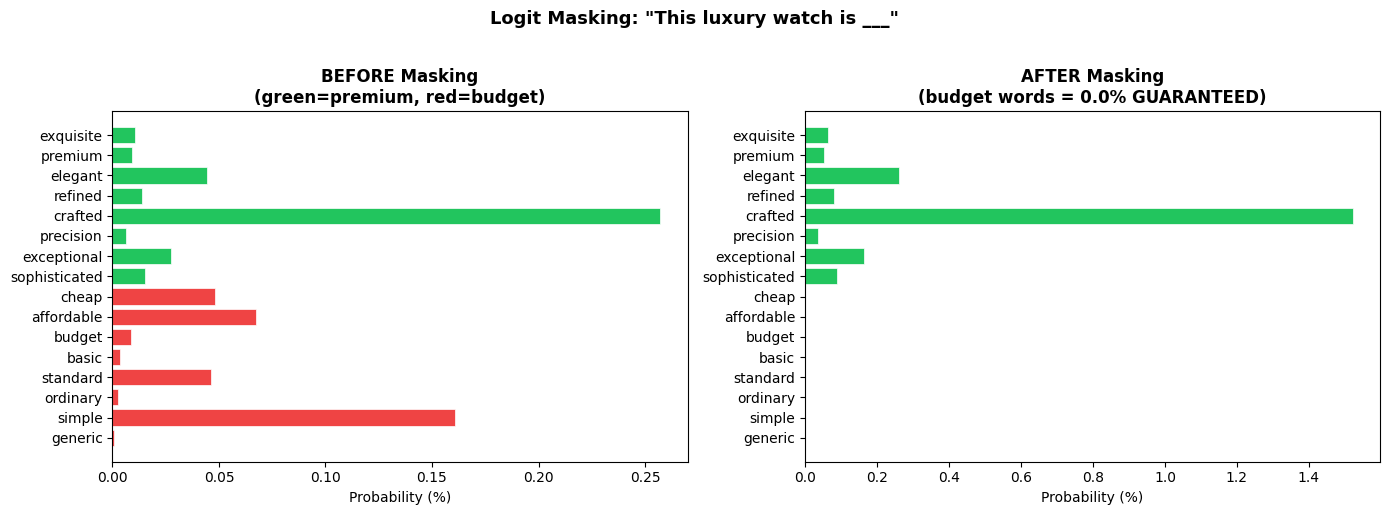

  BEFORE: budget words have non-zero probabilities
  AFTER:  budget words = exactly 0.0% (impossible)
  BONUS:  premium words get MORE probability!


In [17]:
import matplotlib.pyplot as plt
import numpy as np

def before_after_comparison(prompt="This luxury watch is"):
    """
    Visual side-by-side comparison: probabilities with vs without masking.

    Creates a matplotlib chart showing:
      LEFT:  Original probabilities (budget words have non-zero %)
      RIGHT: After masking (budget words = exactly 0.0%)

    This is the visual "proof" that masking works.
    """
    inputs = tokenizer.encode(prompt, return_tensors='pt')
    with torch.no_grad():
        logits = model(inputs).logits[0, -1, :]

    # Words to track in our visualization
    premium_words = [" exquisite", " premium", " elegant", " refined",
                     " crafted", " precision", " exceptional",
                     " sophisticated"]
    budget_words = [" cheap", " affordable", " budget", " basic",
                    " standard", " ordinary", " simple", " generic"]
    all_tracked = premium_words + budget_words

    # Original probabilities (no masking)
    original_probs = F.softmax(logits, dim=0)

    # Build the allowed set (premium + structural words only)
    allowed_ids = set()
    structural = [" a", " an", " the", " with", " and", " of",
                  " truly", " very", " remarkably", ".", ",", "!"]
    for w in premium_words + structural:
        ids = tokenizer.encode(w, add_special_tokens=False)
        allowed_ids.update(ids)

    # Masked probabilities
    masked_logits = apply_logit_mask(logits, allowed_ids)
    masked_probs = F.softmax(masked_logits, dim=0)

    # Collect data
    labels, before_vals, after_vals, colors_before = [], [], [], []
    for w in all_tracked:
        ids = tokenizer.encode(w, add_special_tokens=False)
        if ids:
            tid = ids[0]
            labels.append(w.strip())
            before_vals.append(original_probs[tid].item() * 100)
            after_vals.append(masked_probs[tid].item() * 100)
            colors_before.append(
                '#22c55e' if w in premium_words else '#ef4444'
            )

    # --- Create visualization ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    y = range(len(labels))

    # Left: BEFORE masking
    ax1.barh(y, before_vals, color=colors_before,
             edgecolor='white', linewidth=0.5)
    ax1.set_yticks(y)
    ax1.set_yticklabels(labels, fontsize=10)
    ax1.set_xlabel('Probability (%)')
    ax1.set_title('BEFORE Masking\n(green=premium, red=budget)',
                   fontweight='bold')
    ax1.invert_yaxis()

    # Right: AFTER masking
    colors_after = ['#22c55e' if w in premium_words else '#d1d5db'
                    for w in all_tracked]
    ax2.barh(y, after_vals, color=colors_after,
             edgecolor='white', linewidth=0.5)
    ax2.set_yticks(y)
    ax2.set_yticklabels(labels, fontsize=10)
    ax2.set_xlabel('Probability (%)')
    ax2.set_title('AFTER Masking\n(budget words = 0.0% GUARANTEED)',
                   fontweight='bold')
    ax2.invert_yaxis()

    plt.suptitle(f'Logit Masking: "{prompt} ___"',
                 fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig("before_after_masking.png", dpi=150, bbox_inches='tight')
    plt.show()

    print("  BEFORE: budget words have non-zero probabilities")
    print("  AFTER:  budget words = exactly 0.0% (impossible)")
    print("  BONUS:  premium words get MORE probability!")

before_after_comparison()

### The Dual Effect

Look closely — the controlled versions don't just **avoid bad words**. They actively **use more premium words**. When you eliminate budget-language paths, the probability mass redistributes onto the remaining premium vocabulary.

**Suppression of bad words + amplification of good words = double win.**

## 9. Dynamic Masking — When the Rules Change Mid-Sentence

Everything so far used a **static mask** — same allowed words every step. But what if the rules need to change *depending on what's already been generated?*

### A simple example to build intuition

Imagine you want the model to generate a **color** followed by a **fruit**:

```
"I love _____ _____"
         ↑       ↑
       COLOR    FRUIT

Step 1: allowed = {red, blue, green}     → model picks "red"
Step 2: allowed = {apple, banana, grape}  → model picks "apple"
Done!   → "I love red apple"
```

**The mask CHANGED between steps.** At step 1, "apple" was blocked. At step 2, "red" was blocked. Each step has its own rules.

**This is dynamic masking.** A function looks at what's been generated so far and decides what's allowed *next*.

### Why does this matter?

This is exactly how **structured output** works under the hood:

- **OpenAI's JSON mode** → after `{`, only allow `"` (start a key). After a key, only allow `:`. After `:`, allow values.
- **Outlines / guidance / LMQL** → build a state machine from your schema, query it at each step

The grammar controls **structure**. The model controls **content**.

In [21]:
# =============================================================
# PART A: The simplest dynamic mask you can imagine
# =============================================================
# Let's start with a tiny example before the real function.
#
# Task: Generate "I bought a [COLOR] [OBJECT]"
#   Step 1 → only colors allowed
#   Step 2 → only objects allowed
#   Step 3 → only punctuation allowed
#
# The "rules" are just a list. Position 0 = colors,
# position 1 = objects, position 2 = end.
# =============================================================

# These are the rules: a list where each position
# has its own set of allowed words
RULES = [
    # Position 0: COLORS
    [" red", " blue", " green", " golden", " silver"],
    # Position 1: OBJECTS
    [" car", " watch", " dress", " ring", " phone"],
    # Position 2: END THE SENTENCE
    [".", "!", "..."],
]


def simple_dynamic_mask(text_so_far):
    """
    Given what's been generated so far, return the allowed
    tokens for the NEXT position.

    How it works:
      1. Count how many words were generated after "a"
      2. That count = which position we're at
      3. Look up RULES[position] for allowed words
      4. Convert those words to token IDs

    Example:
      text = "I bought a"              → 0 words → position 0 → COLORS
      text = "I bought a golden"       → 1 word  → position 1 → OBJECTS
      text = "I bought a golden watch" → 2 words → position 2 → PUNCTUATION
    """
    # Count words generated after "a"
    parts = text_so_far.split(" a")
    if len(parts) < 2:
        return set()
    words_after_a = parts[-1].strip().split()
    position = len(words_after_a)

    # If we've filled all positions, we're done
    if position >= len(RULES):
        return set()

    # Get the allowed words for this position
    allowed_words = RULES[position]

    # Convert words → token IDs (what the model actually uses)
    allowed_ids = set()
    for word in allowed_words:
        ids = tokenizer.encode(word, add_special_tokens=False)
        allowed_ids.update(ids)
    return allowed_ids


# =============================================================
# PART B: The generation loop (same as static, but mask changes)
# =============================================================
#
# IMPORTANT Python concept:
#   We pass simple_dynamic_mask as a FUNCTION REFERENCE
#   (no parentheses = "here's the function, call it later")
#
#   generate_with_dynamic_mask(..., mask_fn=simple_dynamic_mask)
#                                          ^^^^^^^^^^^^^^^^^
#                                    NOT simple_dynamic_mask()
#                                    We're handing over the function,
#                                    NOT calling it right now.
#
#   Then inside the loop, it gets called at each step:
#      allowed_ids = mask_fn(generated_text)
#                    ^^^^^^^^^^^^^^^^^^^^^^^^
#                    NOW it's called, with the latest text
#
#   This is called a "callback" — we give the loop a function
#   that it will call back at each step to ask "what's allowed?"
# =============================================================

def generate_with_dynamic_mask(model, tokenizer, prompt, mask_fn,
                               max_new_tokens=10):
    """
    Generate text where allowed tokens CHANGE at each step.

    Almost identical to generate_with_mask (static), with ONE
    key difference: instead of using the same mask every step,
    we CALL mask_fn(text_so_far) to get a fresh mask.

    Think of it like a GPS giving turn-by-turn directions:
      - At each intersection, it looks at where you ARE
      - Then tells you which turns are allowed NOW
      - The allowed turns change as you drive

    Args:
        mask_fn: A FUNCTION (not a value!) that we call at each step.
                 We pass it the text generated so far, and it returns
                 the set of token IDs allowed for the next token.
    """
    input_ids = tokenizer.encode(prompt, return_tensors="pt")
    generated_ids = input_ids[0].tolist()
    generated_text = prompt

    print(f"  Starting: '{prompt}'\n")
    print(f"  {'Step':<6} {'Position':<12} {'Allowed':<35} {'Picked'}")
    print(f"  {'-'*6} {'-'*12} {'-'*35} {'-'*10}")

    for step in range(max_new_tokens):

        # 1. Forward pass (same as always)
        with torch.no_grad():
            outputs = model(torch.tensor([generated_ids]))
            logits = outputs.logits[0, -1, :]

        # 2. Ask: "What's allowed NOW?"
        #    We CALL mask_fn here — this is where it receives
        #    generated_text as its argument (text_so_far)
        allowed_ids = mask_fn(generated_text)

        # 3. If nothing is allowed, the grammar is complete
        if not allowed_ids:
            break

        # 4. Mask + softmax + sample (same as static masking)
        masked_logits = apply_logit_mask(logits, allowed_ids)
        probs = F.softmax(masked_logits, dim=0)
        next_token_id = torch.multinomial(probs, 1).item()

        # 5. Update the text and continue
        generated_ids.append(next_token_id)
        token_str = tokenizer.decode(next_token_id)
        generated_text += token_str

        # Show what happened at this step
        parts = generated_text.split(" a")
        pos = len(parts[-1].strip().split()) - 1 if len(parts) > 1 else 0
        pos_label = ["COLOR", "OBJECT", "END"][min(pos, 2)]
        allowed_preview = RULES[min(pos, len(RULES)-1)][:3]
        print(f"  {step+1:<6} {pos_label:<12} "
              f"{str(allowed_preview):<35} '{token_str.strip()}'")

    return generated_text


# =============================================================
# RUN IT — watch the mask change at each step
# =============================================================
#
# Notice below: we pass simple_dynamic_mask WITHOUT ()
# That means "here's the function" not "run the function"
# The loop will call it at each step with the current text.
# =============================================================

print("DYNAMIC MASKING IN ACTION")
print("=" * 55)
print("  Rule: 'I bought a [COLOR] [OBJECT] [PUNCTUATION]'\n")

for i in range(3):
    result = generate_with_dynamic_mask(
        model, tokenizer,
        "I bought a",
        simple_dynamic_mask,  # ← function REFERENCE, not a call
        max_new_tokens=5
    )
    print(f"\n  Result: '{result}'\n")

print("  " + "=" * 51)
print("  Notice:")
print("    Step 1 → only COLORS were allowed")
print("    Step 2 → colors GONE, only OBJECTS allowed")
print("    Step 3 → objects GONE, only PUNCTUATION allowed")
print()
print("  The RULES decided the structure")
print("  The MODEL decided the content")
print("  That's dynamic masking!")

DYNAMIC MASKING IN ACTION
  Rule: 'I bought a [COLOR] [OBJECT] [PUNCTUATION]'

  Starting: 'I bought a'

  Step   Position     Allowed                             Picked
  ------ ------------ ----------------------------------- ----------
  1      COLOR        [' red', ' blue', ' green']         'red'
  2      OBJECT       [' car', ' watch', ' dress']        'car'
  3      OBJECT       [' car', ' watch', ' dress']        '.'
  4      OBJECT       [' car', ' watch', ' dress']        '...'
  5      OBJECT       [' car', ' watch', ' dress']        '.'

  Result: 'I bought a red car.....'

  Starting: 'I bought a'

  Step   Position     Allowed                             Picked
  ------ ------------ ----------------------------------- ----------
  1      COLOR        [' red', ' blue', ' green']         'blue'
  2      OBJECT       [' car', ' watch', ' dress']        'dress'
  3      OBJECT       [' car', ' watch', ' dress']        '.'
  4      OBJECT       [' car', ' watch', ' dress']    

### From our toy example to real-world structured output

Our `[COLOR] [OBJECT] [PUNCTUATION]` example is tiny, but the pattern is **identical** to how production tools work:

| Our Example | Real-World (JSON mode) |
|---|---|
| Position 0 → colors | After `{` → only allow `"` |
| Position 1 → objects | After `"name"` → only allow `:` |
| Position 2 → punctuation | After `:` → allow `"`, digits, `true` |
| `RULES` list | Finite State Machine (FSM) |
| `simple_dynamic_mask()` | Schema-aware mask function |

**The scale changes, the principle doesn't.** Instead of 3 positions with 5 words each, a JSON schema mask might have hundreds of states with thousands of valid tokens. But at each step, it's still:

1. Look at what's been generated → **where are we in the grammar?**
2. Query the grammar → **what tokens are valid here?**
3. Mask everything else → **-infinity**
4. Model picks the best valid token → **intelligence preserved**

This is how **Outlines**, **guidance**, **LMQL**, and **OpenAI's `response_format`** work under the hood.

```
Your schema:      {"name": ___, "age": ___, "role": ___}
Model's freedom:  "Alice",       25,         "engineer"
```

**The grammar channels the model's intelligence — it doesn't replace it.**

## 10. Tips, Tricks, and Gotchas

In [22]:
# =============================================================
# GOTCHAS: Things that will bite you if you don't know them
# =============================================================

# --- GOTCHA 1: Space variants ---
print("GOTCHA 1: 'Paris' ≠ ' Paris'")
print("=" * 50)
print("  Same word, different tokens depending on position:")
print()
for word in ["Paris", " Paris", "paris", " paris"]:
    ids = tokenizer.encode(word, add_special_tokens=False)
    decoded = [tokenizer.decode(id) for id in ids]
    print(f"    '{word:8s}' → IDs: {str(ids):12s}  "
          f"tokens: {decoded}")
print()
print("  → Ban BOTH variants or your mask has a hole!\n")


# --- GOTCHA 2: Multi-token words ---
print("GOTCHA 2: One word can be MULTIPLE tokens")
print("=" * 50)
for word in ["JavaScript", " JavaScript", "cryptocurrency"]:
    ids = tokenizer.encode(word, add_special_tokens=False)
    decoded = [tokenizer.decode(id) for id in ids]
    print(f"    '{word:16s}' → {len(ids)} token(s): {decoded}")
print()
print("  → Allow ALL sub-tokens, or the model gets stuck\n")


# --- GOTCHA 3: Empty mask ---
print("GOTCHA 3: Never mask EVERYTHING")
print("=" * 50)
all_inf = torch.full((10,), float('-inf'))
result = F.softmax(all_inf, dim=0)
print(f"    softmax(all -inf) = {result[:4]}...")
print("    NaN! Always keep at least one token allowed.\n")


# --- TIP: Temperature + Masking ---
print("TIP: Temperature + Masking = best combo")
print("=" * 50)
print("    Low temp  (0.1) + mask = reliable, predictable")
print("    High temp (2.0) + mask = creative within bounds")
print("    Production recommendation: low temp + masking")

GOTCHA 1: 'Paris' ≠ ' Paris'
  Same word, different tokens depending on position:

    'Paris   ' → IDs: [40313]       tokens: ['Paris']
    ' Paris  ' → IDs: [6342]        tokens: [' Paris']
    'paris   ' → IDs: [1845, 271]   tokens: ['par', 'is']
    ' paris  ' → IDs: [1582, 271]   tokens: [' par', 'is']

  → Ban BOTH variants or your mask has a hole!

GOTCHA 2: One word can be MULTIPLE tokens
    'JavaScript      ' → 2 token(s): ['Java', 'Script']
    ' JavaScript     ' → 1 token(s): [' JavaScript']
    'cryptocurrency  ' → 3 token(s): ['crypt', 'oc', 'urrency']

  → Allow ALL sub-tokens, or the model gets stuck

GOTCHA 3: Never mask EVERYTHING
    softmax(all -inf) = tensor([nan, nan, nan, nan])...
    NaN! Always keep at least one token allowed.

TIP: Temperature + Masking = best combo
    Low temp  (0.1) + mask = reliable, predictable
    High temp (2.0) + mask = creative within bounds
    Production recommendation: low temp + masking


## 11. The Complete Mental Model

Here's the full picture of how LLM output control works:

```
                      The LLM Generation Pipeline
                      ============================

  Input: "This luxury watch is"
          |
          v
  ┌─────────────────────────┐
  │   Transformer Model     │   <-- Deterministic. Same input = same output.
  │   (Billions of params)  │       We don't change this.
  └───────────┬─────────────┘
              |
              v
      Raw Logits [50,257 scores]
              |
  ╔═══════════╧═══════════════╗
  ║   LOGIT MASKING ZONE      ║   <-- THIS IS WHERE YOU INTERVENE
  ║                           ║
  ║   Set banned --> -inf     ║   Static: word blocklist
  ║   Keep allowed --> as-is  ║   Dynamic: grammar/JSON/regex
  ╚═══════════╤═══════════════╝
              |
      Temperature Scaling          <-- Controls confidence
              |
      Top-k / Top-p                <-- Prunes low-prob tail
              |
          Softmax --> Probabilities
              |
          Sample --> Next Token     <-- ONLY random step
              |
  "This luxury watch is exquisite"
```

### The Key Distinctions

**Temperature/Top-K/Top-P** control HOW we draw from the distribution.
They make unlikely things more/less likely. But "unlikely" is not "impossible."

**Logit masking** controls WHAT exists in the distribution.
It makes banned things have probability = exactly zero = mathematically impossible.

> Think of it as moving from "influence" to **control**.
> Once you internalize that, you can design LLM systems with predictable behavior at scale.

## Key Takeaways

**1. LLMs are deterministic.** Same input = same logits, every time. The randomness is only in sampling.

**2. Traditional controls can't give guarantees.** Temperature, top-k, top-p reduce violations but can't eliminate them. Any token with probability > 0 will eventually appear.

**3. Logit masking = mathematical guarantee.** Setting logits to -inf before softmax makes probability exactly zero. Not low. Zero.

**4. Static masking** uses a fixed allowed/banned set. Good for word filters, brand compliance, content safety.

**5. Dynamic masking** changes the allowed set every step based on a grammar/FSM. This is how Outlines, guidance, LMQL, and OpenAI's JSON mode work under the hood.

**6. The model stays smart.** You change what it can SAY, not what it KNOWS. Within the allowed vocabulary, it still picks the best option.

---

### Where to Go From Here

- **[Outlines](https://github.com/outlines-dev/outlines)** — Production-ready structured generation with regex/JSON schemas
- **[guidance](https://github.com/guidance-ai/guidance)** — Microsoft's constrained generation framework
- **[LMQL](https://lmql.ai/)** — Query language for LLM constraints
- **[HuggingFace LogitsProcessor](https://huggingface.co/docs/transformers/main_classes/logits_process)** — The built-in API for logit manipulation

---

*Built from scratch. No magic. Just logits and math.*